# 02. Similarity of strong perturbations: CORUM validation, clustering and MDE (Fig. 2B, 2D)

Expression profiles of the strong perturbations (notebook 01) are compared over a set of highly variable,
well-expressed genes (`gwps.select_genes`, an approximation of the paper's 2,319 genes). The target gene of
each perturbation is set to 0 before computing correlations, as in the paper.

In [1]:
import sys; sys.path.insert(0, "../src")
import itertools
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import mannwhitneyu
from sklearn.cluster import HDBSCAN
import gwps

gw = gwps.load("k562_gw")
cls = pd.read_csv(gwps.RES / "k562_gw_classes.csv", index_col=0)["class"]
strong = cls.index[cls == "strong"]
genes = gwps.select_genes(gw, strong)
P = gwps.profiles(gw[strong], genes)
targets = gw.obs.loc[strong, "target"]
print(f"{len(strong)} strong perturbations x {len(genes)} genes")
pd.Series(genes, name="gene_id").to_csv(gwps.RES / "k562_gw_selected_genes.csv", index=False)

1962 strong perturbations x 2273 genes


## Report Fig. 3 (left, middle): expression profiles and correlation matrix of the strong perturbations (cf. paper Fig. 2A)

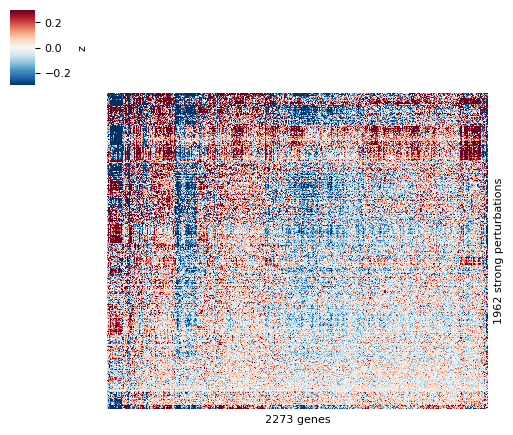

In [2]:
g = sns.clustermap(P.values, cmap=gwps.EXPR_CMAP, vmin=-0.3, vmax=0.3, figsize=(5, 4.2), method="average",
                   xticklabels=False, yticklabels=False, rasterized=True, cbar_kws={"label": "z"})
g.ax_row_dendrogram.set_visible(False); g.ax_col_dendrogram.set_visible(False)
g.ax_heatmap.set_xlabel(f"{len(genes)} genes"); g.ax_heatmap.set_ylabel(f"{len(strong)} strong perturbations")
gwps.savefig(g.fig, "fig03a_expression")

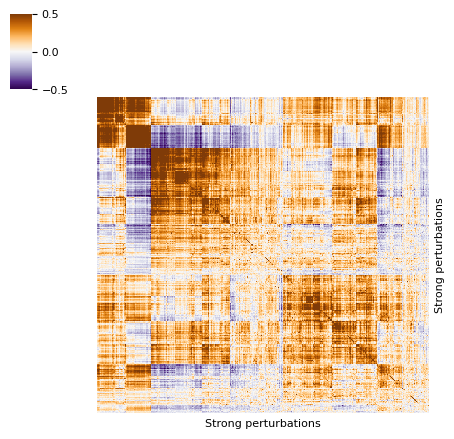

In [3]:
corr = np.corrcoef(P.values)
g = sns.clustermap(corr, cmap=gwps.CORR_CMAP, vmin=-0.5, vmax=0.5, figsize=(4.4, 4.2), method="average",
                   xticklabels=False, yticklabels=False, rasterized=True)
g.ax_row_dendrogram.set_visible(False); g.ax_col_dendrogram.set_visible(False)
g.ax_heatmap.set_xlabel("Strong perturbations"); g.ax_heatmap.set_ylabel("Strong perturbations")
gwps.savefig(g.fig, "fig03b_correlation")

## Report Fig. 3 (right): perturbations of the same CORUM complex are correlated (cf. paper Fig. 2B)

The paper used the CORUM 3.0 core complexes (03.09.2018) and kept complexes with at least 66% of their
subunits among the strong perturbations (327 complexes, 14,165 pairs). CORUM could not be downloaded
from the compute cluster, so the CORUM library distributed by Enrichr (human complexes only) is used.

174 complexes, 3624 pairs in a complex; median r = 0.60 (complex) vs 0.10 (other pairs); one-sided Mann-Whitney p = 0.0e+00


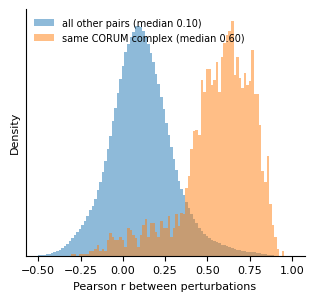

In [4]:
corum = gwps.read_gmt(gwps.DATA / "CORUM_enrichr.gmt", suffix="(human)")
present = set(targets)
kept = {k: v for k, v in corum.items() if np.mean([g in present for g in set(v)]) >= 0.66}
pos = pd.Series(np.arange(len(strong)), index=strong)
by_gene = targets.groupby(targets).groups
pairs = set()
for members in kept.values():
    for g1, g2 in itertools.combinations(sorted(set(members) & present), 2):
        for p1, p2 in itertools.product(by_gene[g1], by_gene[g2]):
            i, j = sorted((pos[p1], pos[p2]))
            pairs.add((i, j))
pairs = np.array(sorted(pairs))
in_complex = np.zeros_like(corr, dtype=bool)
in_complex[pairs[:, 0], pairs[:, 1]] = True
iu = np.triu_indices_from(corr, k=1)
r_complex = corr[iu][in_complex[iu]]
r_other = corr[iu][~in_complex[iu]]
p = mannwhitneyu(r_complex, r_other, alternative="greater").pvalue
print(f"{len(kept)} complexes, {len(r_complex)} pairs in a complex; "
      f"median r = {np.median(r_complex):.2f} (complex) vs {np.median(r_other):.2f} (other pairs); "
      f"one-sided Mann-Whitney p = {p:.1e}")

fig, ax = plt.subplots(figsize=(3.6, 3.2))
ax.hist(r_other, bins=100, range=(-0.5, 1), density=True, alpha=0.5, label=f"all other pairs (median {np.median(r_other):.2f})")
ax.hist(r_complex, bins=100, range=(-0.5, 1), density=True, alpha=0.5, label=f"same CORUM complex (median {np.median(r_complex):.2f})")
ax.set_xlabel("Pearson r between perturbations"); ax.set_ylabel("Density"); ax.set_yticks([])
ax.legend(frameon=False, loc="upper left")
gwps.savefig(fig, "fig03c_corum")

## Report Fig. 4: HDBSCAN clusters and minimum-distortion embedding (cf. paper Fig. 2D)

Paper settings: HDBSCAN on correlation distances (`metric='precomputed', min_cluster_size=4, min_samples=1,
cluster_selection_method='eom'`; 63-64 clusters). MDE (`preserve_neighbors`, `n_neighbors=7`,
`repulsive_fraction=5`) of the standardized profiles, initialized with a spectral embedding.

In [5]:
dist = np.clip(1 - corr, 0, None)
labels = HDBSCAN(metric="precomputed", min_cluster_size=4, min_samples=1,
                 cluster_selection_method="eom", copy=False).fit_predict(dist)
print(f"{labels.max() + 1} clusters, {np.mean(labels == -1):.0%} of perturbations unassigned")
pd.DataFrame({"target": targets, "cluster": labels}).to_csv(gwps.RES / "k562_gw_strong_clusters.csv")

63 clusters, 64% of perturbations unassigned


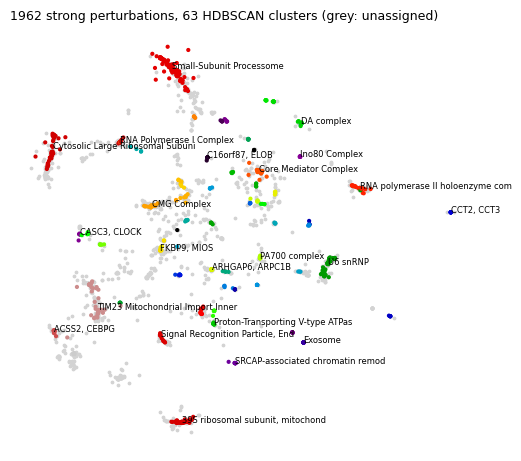

In [6]:
xy = gwps.mde(gwps.standardize_rows(P.values), dim=2)

fig, ax = plt.subplots(figsize=(6, 5.5))
noise = labels == -1
ax.scatter(*xy[noise].T, s=3, c="lightgrey")
ax.scatter(*xy[~noise].T, s=4, c=labels[~noise], cmap="nipy_spectral")
# label large clusters with the best-matching complex (GO CC or CORUM, >= 3 shared targets), else two members
names = gwps.cluster_names(targets, labels, gwps.complex_library())
for k, text in names.items():
    m = labels == k
    if m.sum() >= 8:
        ax.text(*np.median(xy[m], 0), text, fontsize=6)
ax.set_xticks([]); ax.set_yticks([]); [s.set_visible(False) for s in ax.spines.values()]
ax.set_title(f"{len(strong)} strong perturbations, {labels.max() + 1} HDBSCAN clusters (grey: unassigned)", loc="left")
gwps.savefig(fig, "fig04_mde_clusters")